**Sử dụng Generative AI**: Đối với các bài tập này, việc sử dụng AI tạo sinh tuân theo các chính sách tương tự về sự hợp tác. Giống như với các cộng tác viên khác, mỗi sinh viên phải tự viết các giải pháp một cách độc lập khỏi kết quả tương tác và bài nộp phải bao gồm một ghi chú chỉ rõ bản chất của sự hợp tác. Việc sử dụng các công cụ AI tạo sinh để hoàn thành phần lớn nội dung của bài tập là không phù hợp với tinh thần của bài tập, và sẽ vi phạm [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

# Bài tập Phân loại Softmax

*Hoàn thành và nộp bảng bài tập đã hoàn chỉnh này (bao gồm các outputs của nó và bất kỳ code hỗ trợ nào bên ngoài bảng bài tập) cùng với bài nộp của bạn. Để biết thêm chi tiết, xem [trang bài tập](http://vision.stanford.edu/teaching/cs231n/assignments.html) trên trang web của khóa học.*

Trong bài tập này, bạn sẽ:
    
- thực hiện một **hàm loss** được vector hóa hoàn toàn cho bộ phân loại Softmax.
- thực hiện biểu thức vector hóa hoàn toàn cho **gradient giải tích** của nó.
- **kiểm tra việc thực hiện của bạn** bằng cách sử dụng gradient số học.
- sử dụng một tập xác thực (validation set) để **tinh chỉnh learning rate (tốc độ học) và regularization (chính quy hóa)**.
- **tối ưu hóa** hàm loss bằng **SGD**.
- **trực quan hóa** các trọng số học được cuối cùng.

In [7]:
# Chạy một số mã thiết lập cho notebook này.
import random
import numpy as np
import matplotlib.pyplot as plt

# Đây là một chút kỹ thuật (magic) để làm cho các hình matplotlib hiển thị trực tiếp (inline)
# trong notebook thay vì mở trong một cửa sổ mới.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # thiết lập kích thước mặc định của các biểu đồ
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Thêm một số magic code để notebook tự động tải lại các module python bên ngoài;
# xem http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# %load_ext autoreload
# %autoreload 2

## Tải và Tiền xử lý dữ liệu CIFAR-10 (Đã chuyển sang Bộ dữ liệu Hoa)

In [8]:
import os
import numpy as np
from PIL import Image

def load_flower_data(data_dir, img_size=(32, 32)):
    classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
    X = []
    y = []
    
    for label, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                X.append(np.array(img))
                y.append(label)
            except Exception as e:
                pass
                
    X = np.array(X).astype('float64')
    y = np.array(y)
    
    # Xáo trộn (Shuffle) dữ liệu
    np.random.seed(42)
    idxs = np.random.permutation(len(X))
    X = X[idxs]
    y = y[idxs]
    return X, y

# Tải dữ liệu hoa thô
dataset_dir = 'flower-training'

try:
   del X_train, y_train
   del X_test, y_test
   print('Xóa sạch dữ liệu đã tải trước đó.')
except:
   pass

X_data, y_data = load_flower_data(dataset_dir)
print('Tổng kích thước dữ liệu (Total data shape): ', X_data.shape)
print('Tổng kích thước nhãn (Total labels shape): ', y_data.shape)

# Tạo một bộ chia thủ công (80% train, 20% test)
num_samples = len(X_data)
split_idx = int(0.8 * num_samples)

X_train, y_train = X_data[:split_idx], y_data[:split_idx]
X_test, y_test = X_data[split_idx:], y_data[split_idx:]

print('Kích thước tập huấn luyện (Training data shape): ', X_train.shape)
print('Hình dạng nhãn huấn luyện (Training labels shape): ', y_train.shape)
print('Kích thước tập kiểm tra (Test data shape): ', X_test.shape)
print('Hình dạng nhãn kiểm tra (Test labels shape): ', y_test.shape)

Xóa sạch dữ liệu đã tải trước đó.
Tổng kích thước dữ liệu (Total data shape):  (2746, 32, 32, 3)
Tổng kích thước nhãn (Total labels shape):  (2746,)
Kích thước tập huấn luyện (Training data shape):  (2196, 32, 32, 3)
Hình dạng nhãn huấn luyện (Training labels shape):  (2196,)
Kích thước tập kiểm tra (Test data shape):  (550, 32, 32, 3)
Hình dạng nhãn kiểm tra (Test labels shape):  (550,)


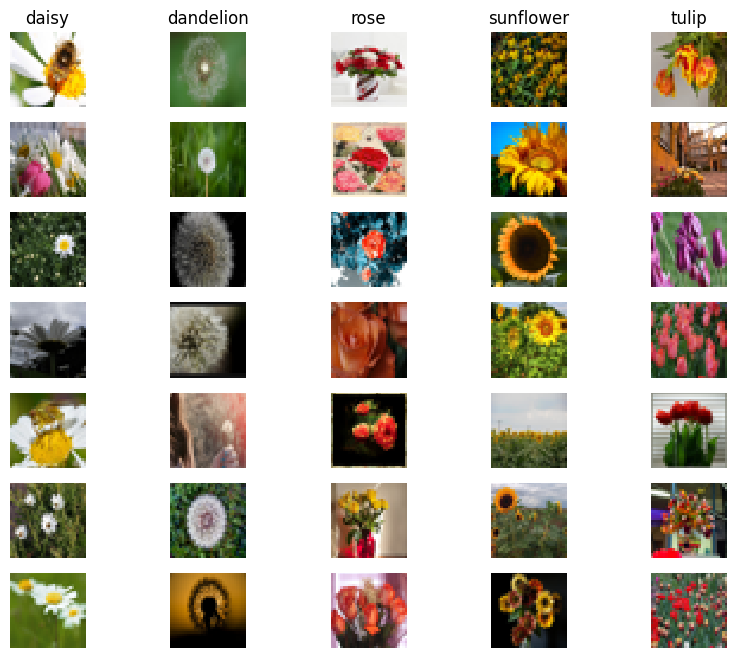

In [9]:
# Trực quan hóa một số ví dụ từ bộ dữ liệu.
# Chúng ta hiển thị một vài ví dụ về hình ảnh huấn luyện từ mỗi lớp.
classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    if len(idxs) == 0:
        continue
    samples = min(samples_per_class, len(idxs))
    idxs = np.random.choice(idxs, samples, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [10]:
# Chia các dữ liệu thành các tập train, val, và test. Ngoài ra chúng ta sẽ
# tạo một tập development (phát triển) nhỏ là một tập con của tập dữ liệu huấn luyện;
# chúng ta có thể sử dụng cái này cho quá trình phát triển để code chạy nhanh hơn.
num_training = int(len(X_train) * 0.9)  # 90% của train dành cho quá trình train
num_validation = len(X_train) - num_training  # 10% của train dành cho validation (xác thực)
num_test = len(X_test)
num_dev = min(500, num_training)

print(f'Chi tiết chia tập: Train: {num_training}, Val: {num_validation}, Test: {num_test}, Dev: {num_dev}')

# Tập validation của chúng ta sẽ gồm num_validation điểm dữ liệu từ tập huấn luyện gốc.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Tập huấn luyện của chúng ta sẽ gồm một lượng num_train điểm đầu tiên từ tập huấn luyện gốc.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Chúng ta cũng sẽ tạo ra một tập dev, vốn là một tập con nhỏ từ tập huấn luyện chính.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Chúng ta sử dụng y nguyên tập dữ liệu Test gốc
X_test = X_test[:]
y_test = y_test[:]

print('Kích thước tập huấn luyện (Train data shape): ', X_train.shape)
print('Kích thước nhãn huấn luyện: ', y_train.shape)
print('Kích thước tập validation (Validation data shape): ', X_val.shape)
print('Kích thước nhãn validation: ', y_val.shape)
print('Kích thước tập kiểm tra (Test data shape): ', X_test.shape)
print('Kích thước nhãn kiểm tra: ', y_test.shape)

Chi tiết chia tập: Train: 1976, Val: 220, Test: 550, Dev: 500
Kích thước tập huấn luyện (Train data shape):  (1976, 32, 32, 3)
Kích thước nhãn huấn luyện:  (1976,)
Kích thước tập validation (Validation data shape):  (220, 32, 32, 3)
Kích thước nhãn validation:  (220,)
Kích thước tập kiểm tra (Test data shape):  (550, 32, 32, 3)
Kích thước nhãn kiểm tra:  (550,)


In [11]:
# Tiền xử lý: thay đổi hình dáng (reshape) khối dữ liệu hình ảnh thành các hàng
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# Kiểm tra đảm bảo cấu trúc dữ liệu, in ra hình dáng (shapes) của các biến dữ liệu
print('Kích thước tập huấn luyện: ', X_train.shape)
print('Kích thước tập validation: ', X_val.shape)
print('Kích thước tập kiểm tra: ', X_test.shape)
print('Kích thước tập dev: ', X_dev.shape)

Kích thước tập huấn luyện:  (1976, 3072)
Kích thước tập validation:  (220, 3072)
Kích thước tập kiểm tra:  (550, 3072)
Kích thước tập dev:  (500, 3072)


[ 99.25708502 100.50759109  84.22672065 100.9757085  102.05161943
  85.15840081 103.01923077 103.97621457  86.70242915 105.26417004]


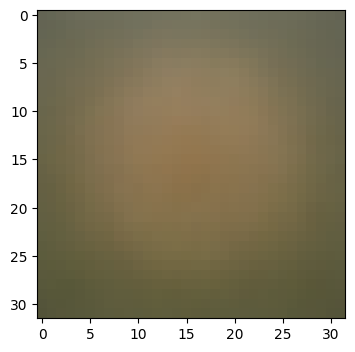

(1976, 3073) (220, 3073) (550, 3073) (500, 3073)


In [12]:
# Tiền xử lý: trừ đi hình ảnh trung bình (mean image)
# đầu tiên: tính toán ảnh trung bình dựa trên dữ liệu training
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # In ra một vài phần tử
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # trực quan hóa bức ảnh trung bình
plt.show()

# bước 2: trừ đi bức ảnh trung bình khỏi phần dữ liệu của train và test
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# bước 3: nối thêm (append) một chiều thiên kiến (bias) chỉ toàn các số một (tức là thủ thuật bias) 
# để cho bộ phân loại (classifier) của chúng ta chỉ cần quan tâm tới việc tối ưu hóa một ma trận trọng số duy nhất W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Bộ phân loại Softmax

Mã nguồn của bạn cho phần này bình thường được viết tại file trong `cs231n/classifiers/softmax.py`.

Như bạn thấy, chúng ta đã được điền sẵn hoặc chèn sẵn hàm `softmax_loss_naive` vốn có sử dụng các vòng lặp for (for loops) để tính toán hàm mất mát softmax (softmax loss function).

In [13]:
# Đánh giá cách thực hiện mã loss cơ bản (naive) mà chúng tôi cung cấp cho bạn:
import time

def softmax_loss_naive(W, X, y, reg):
    """
    Hàm mất mát Softmax, triển khai cơ bản naive (bằng vòng lặp)
    """
    loss = 0.0
    dW = np.zeros_like(W)
    num_classes = W.shape[1]
    num_train = X.shape[0]

    for i in range(num_train):
        scores = X[i].dot(W)
        scores -= np.max(scores) # Ổn định tính toán số học
        probs = np.exp(scores) / np.sum(np.exp(scores))
        loss += -np.log(probs[y[i]])
        
        for j in range(num_classes):
            if j == y[i]:
                dW[:, j] += (probs[j] - 1) * X[i]
            else:
                dW[:, j] += probs[j] * X[i]

    loss /= num_train
    dW /= num_train

    loss += reg * np.sum(W * W)
    dW += 2 * reg * W

    return loss, dW


# Tọa một ma trận Softmax trọng số classifier nhẫu nhiên với nhưng con số cực kì nhỏ
# Lưu ý: chúng ta hiện mang 5 lớp (class) hoa ở đây thay vì 10
W = np.random.randn(3073, 5) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# Để sanity check sơ qua, loss của chúng ta nên cần nằm loanh quanh vào khoảng -log(0.2).
print('loss: %f' % loss)
print('sanity check (đánh giá kiểm tình an toàn): %f' % (-np.log(0.2)))

loss: 1.668061
loss: 1.668061
sanity check (đánh giá kiểm tình an toàn): 1.609438


**Câu hỏi Trực tiếp 1**

Tại sao chúng ta kỳ vọng loss của mình sẽ gần với -log(0.2)? Vui lòng giải thích ngắn gọn.**

$\color{blue}{\textit Câu trả lời của bạn:}$ *Vì có 5 lớp nên 1/5 = 0,2 mà theo công thức thì $L = -\log(P_{\text{correct}})$*




Giá trị `grad` được trả về từ hàm ở trên hiện tại đều là số 0. Hãy dẫn xuất và viết code hệ số gradient cho hàm loss softmax và cài đặt đoạn mã đó ngay bên trong hàm `softmax_loss_naive`. Bạn sẽ nhận thấy sự tiện lợi khi lồng phần code mới của bạn vào trong hàm hiện tại.

Để kiểm tra xem bạn đã cài đặt độ lệch gradient chính xác chưa, bạn có thể ước tính số học độ dốc của hàm mất mát và đối chiếu giá trị ước tính đó bằng mô phỏng với con số gradient bạn mới tính được để so. Chúng tôi đã viết sẵn mã code giúp bạn làm việc đó ở phía dưới đây:

In [14]:
# Một khi bạn đã thiết lập gradient, biểu diễn, tính toán lại nó với đoạn mã sau
# và kiểm tra chéo grad check với hàm có sẵn.

# Hãy tính loss và gradient tại điểm ma trận W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

def grad_check_sparse(f, x, analytic_grad, num_checks=10, h=1e-5):
    """
    Kéo một vài biến bất kì bằng random elements và chỉ trả ra dữ liệu kết quả phân tích số học
    ở trong các dimensions tương ứng này.
    """
    for i in range(num_checks):
        ix = tuple([random.randrange(m) for m in x.shape])
        
        oldval = x[ix]
        x[ix] = oldval + h
        fxph = f(x)
        x[ix] = oldval - h
        fxmh = f(x)
        x[ix] = oldval

        grad_numerical = (fxph - fxmh) / (2 * h)
        grad_analytic = analytic_grad[ix]
        rel_error = abs(grad_numerical - grad_analytic) / (abs(grad_numerical) + abs(grad_analytic) + 1e-8)
        print('kết quả số học: %f \tkết quả phân tích tính toán (analytic): %f\t| \ttỷ lệ chênh lệch lỗi: %e' % (grad_numerical, grad_analytic, rel_error))

# Tự động tính thử số học số đo gradient dọc theo vài chiều lấy ngẫu nhiên và
# khớp lại so độ lệch với số phân tích tính toán bằng toán được ở trên. Kết quả
# nên gần như tương hợp hoàn toàn, đồng đều mọi biên.
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

print("\nVới Regularization chạy cùng:")
# Tiến hành lặp lại check gradient cùng lúc thêm với hệ số tối ưu Regularization đã kích hoạt
# hy vọng không bị lãng quên Regularization trong gradient bạn nha?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

kết quả số học: -0.753068 	kết quả phân tích tính toán (analytic): -0.753068	| 	tỷ lệ chênh lệch lỗi: 4.755136e-08
kết quả số học: 1.589636 	kết quả phân tích tính toán (analytic): 1.589636	| 	tỷ lệ chênh lệch lỗi: 9.035694e-08
kết quả số học: -2.839618 	kết quả phân tích tính toán (analytic): -2.839619	| 	tỷ lệ chênh lệch lỗi: 9.893303e-08
kết quả số học: -1.164440 	kết quả phân tích tính toán (analytic): -1.164441	| 	tỷ lệ chênh lệch lỗi: 4.243093e-08
kết quả số học: -1.794534 	kết quả phân tích tính toán (analytic): -1.794534	| 	tỷ lệ chênh lệch lỗi: 2.668866e-08
kết quả số học: 0.957182 	kết quả phân tích tính toán (analytic): 0.957181	| 	tỷ lệ chênh lệch lỗi: 2.463581e-07
kết quả số học: 1.596302 	kết quả phân tích tính toán (analytic): 1.596302	| 	tỷ lệ chênh lệch lỗi: 7.169559e-08
kết quả số học: 1.279882 	kết quả phân tích tính toán (analytic): 1.279882	| 	tỷ lệ chênh lệch lỗi: 6.322772e-08
kết quả số học: -2.292772 	kết quả phân tích tính toán (analytic): -2.292772	| 	tỷ lệ ch

**Câu hỏi trực tiếp 2**

Dẫu rằng phương pháp gradcheck mang độ tin cậy ổn với hàm mất mát theo dạng softmax, nhưng có một thực tế là đối diện với phân cực cho class loss của SVM, thi thoảng sẽ có 1 chiều của gradcheck bị lệch xê dịch, không hoàn toàn khớp tuyệt đối 100%. Vậy có thể gì là cội rễ khởi thủy của sự khác biệt này? Liệu đôi khi điều này trở thành một mối lưu tâm? Đâu có thể là minh chứng minh họa điển hình một chiều cụ thế chừng nào gradient loss của SVM bị check failed (không khớp chính xác)? Theo góc nhận định của bạn, giả sử thay đổi vùng biên margin thì liệu sẽ tác động được biến thiên ra sao đến tần suất xảy ra chệch choạng kia không?

Nhớ rõ rằng hàm suy hao của SVM về 1 chiều phân kỳ $(x_i, y_i)$ có định nghĩa tương ứng: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ trong đó với $j$ thực hiện luân chuyển xoay qua toàn dải class thay trừ ra $y_i$ lớp đúng đã chọn và còn $s_j$ được tính làm giá trị độ điểm score mà trình phân lớp phân ra. $\Delta$ mang vị thế là đại lượng biên sai margin đơn chiều. Vui lòng tham khảo thêm tham chiếu về 'Hàm tổn thất SVM nhiều cực lớp phân nhánh' (Multiclass Support Vector Machine loss) trên trang [sau](https://cs231n.github.io/linear-classify/).

*Gợi mở (Hint): thực ra thì hàm giá trị loss SVM nói theo phương diện chặt chẽ không khả vi, không vi phân (không lấy vi phân được).*


$\color{blue}{\textit Câu trả lời của bạn:}$ *Nguyên nhân cốt lõi là do hàm loss SVM chứa hàm $\max(0, x)$, tạo ra một "điểm gãy" không thể lấy đạo hàm. Khi bước nhảy nhỏ của gradcheck vô tình vắt ngang qua điểm gãy này, máy tính sẽ tính ra sai số lớn so với công thức toán học.Tuy nhiên, điều này không đáng lo ngại vì xác suất rơi trúng điểm gãy là rất thấp, và thuật toán tối ưu vẫn xử lý mượt mà nhờ khái niệm đạo hàm dưới (subgradient). Việc thay đổi biên margin $\Delta$ cũng chỉ làm xê dịch vị trí điểm gãy trên trục tọa độ, hoàn toàn không làm thay đổi tần suất xảy ra sự chệch choạng này.*  

In [15]:
def softmax_loss_vectorized(W, X, y, reg):
    """
    Hàm mất mát Softmax, phiên bản được vector hóa (vectorized version).
    """
    loss = 0.0
    dW = np.zeros_like(W)
    num_train = X.shape[0]
    
    scores = X.dot(W)
    scores -= np.max(scores, axis=1, keepdims=True)
    probs = np.exp(scores) / np.sum(np.exp(scores), axis=1, keepdims=True)
    
    correct_logprobs = -np.log(probs[range(num_train), y])
    loss = np.sum(correct_logprobs) / num_train
    loss += reg * np.sum(W * W)
    
    dscores = probs
    dscores[range(num_train), y] -= 1
    dscores /= num_train
    
    dW = X.T.dot(dscores)
    dW += 2 * reg * W
    
    return loss, dW

# Tiếp theo thực hiện hàm softmax_loss_vectorized; hiện tại chỉ cần tính ra mốc loss;
# chúng ta sẽ chèn mã tính gradient vector tiếp ở ngay liền kề sau.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e tính toán ra trong %f giây (s)' % (loss_naive, toc - tic))

tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e tính toán ra trong %f giây (s)' % (loss_vectorized, toc - tic))

# The losses (mất mát) nên mang dáng vẻ hệt nhau ngang hàng nhưng bù lại dạng thực hiện 
# biểu thức qua vector này mang dấp tính toán nhanh nhẹn nhanh vượt trội.
print('Độ lệch khác biệt đo ra: %f' % (loss_naive - loss_vectorized))

Naive loss: 1.668061e+00 tính toán ra trong 0.016038 giây (s)
Vectorized loss: 1.668061e+00 tính toán ra trong 0.005942 giây (s)
Độ lệch khác biệt đo ra: -0.000000


In [16]:
# Điền và hoàn tất trọn bộ các cài đặt còn thiếu của hàm softmax_loss_vectorized, và tính toán
# lấy giá trị grad cho hàm suy hao dựa trên dáng dấp phép tính vector hóa.

# Các triển khai dạng sơ đẳng naive bằng vòng lặp và hình thức tối giản qua tính vector phải có mặt
# giá trị tương hợp; song bù trừ thì qua tính toán bằng cơ thức mảng vectorization phải thể hiện tốc độ nhanh vút.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss và gradient: đã xử tính xong trong quãng %f giây (s)' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss và gradient: đã xử tính xong trong %f giây (s)' % (toc - tic))

# Vốn dĩ giá trị của metric the loss là mang giá trị là một số biểu đồ đơn lẻ độc lập tĩnh, 
# điều đó hỗ trợ tiện tay rà duyệt khớp qua thông số qua 2 bên biểu thức độc lập rất là giản đơn gẩy mắt 1 lần thôi.
# Dẫu cho vậy với hàm lượng giá trị gradient trả thì là lại 1 ma trận khối đa diện, vì dẫu cớ trớ thế 
# nên quy theo chuẩn chẩn mực hóa Frobenius (Frobenius norm/chuẩn 2) là chuẩn để lấy ra quy định đối chiếu ma trận .
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Khác biệt gradient matrix theo chuẩn quy đổi: %f' % difference)

Naive loss và gradient: đã xử tính xong trong quãng 0.016301 giây (s)
Vectorized loss và gradient: đã xử tính xong trong 0.001574 giây (s)
Khác biệt gradient matrix theo chuẩn quy đổi: 0.000000


### Stochastic Gradient Descent (Độ dốc Giảm dần ngẫu nhiên Stochastic)

Tới đoạn này chúng ta xem ra dắt túi sẵn công cụ đo hao loss và dốc gradient bằng biểu thị hàm vectorization vector hóa nhanh tút gọn. Biểu thức biểu chứng được đối chiếu mang mức gradient ngang đồng giá trị số học. Ta hiển nhiên tịnh tiến sang sẵn sàng bắt đầu chui vào phần chạy phương án SGD nhằm để kìm co lại mức hao. Code bạn chắp bút sẽ cần nằm quy ngay bên dưới.

In [17]:
class LinearClassifier(object):

    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=100,
              batch_size=200, verbose=False):
        num_train, dim = X.shape
        num_classes = np.max(y) + 1 # giả định rằng y đón giá trị nằm rải từ 0...K-1 trong đó mang K nghĩa là số lượng class
        if self.W is None:
            self.W = 0.001 * np.random.randn(dim, num_classes)

        loss_history = []
        for it in range(num_iters):
            batch_idxs = np.random.choice(num_train, batch_size, replace=True)
            X_batch = X[batch_idxs]
            y_batch = y[batch_idxs]

            loss, grad = self.loss(X_batch, y_batch, reg)
            loss_history.append(loss)

            self.W -= learning_rate * grad

            if verbose and it % 100 == 0:
                print('vòng lặp (iteration) %d / %d: loss %f' % (it, num_iters, loss))

        return loss_history

    def predict(self, X):
        y_pred = np.zeros(X.shape[0])
        scores = X.dot(self.W)
        y_pred = np.argmax(scores, axis=1)
        return y_pred
        
    def loss(self, X_batch, y_batch, reg):
        pass

    def save(self, filepath):
        np.save(filepath, self.W)


class Softmax(LinearClassifier):
    def loss(self, X_batch, y_batch, reg):
        return softmax_loss_vectorized(self.W, X_batch, y_batch, reg)

# Cài đặt code train áp chạy mô phỏng chạy hàm 
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('Hoàn thiện ngót nghét tổng thời gian %f s' % (toc - tic))

vòng lặp (iteration) 0 / 1500: loss 389.415510
vòng lặp (iteration) 100 / 1500: loss 142.972714
vòng lặp (iteration) 200 / 1500: loss 53.096520
vòng lặp (iteration) 300 / 1500: loss 20.353325
vòng lặp (iteration) 400 / 1500: loss 8.301246
vòng lặp (iteration) 500 / 1500: loss 3.881287
vòng lặp (iteration) 600 / 1500: loss 2.322128
vòng lặp (iteration) 700 / 1500: loss 1.768250
vòng lặp (iteration) 800 / 1500: loss 1.491973
vòng lặp (iteration) 900 / 1500: loss 1.458946
vòng lặp (iteration) 1000 / 1500: loss 1.422701
vòng lặp (iteration) 1100 / 1500: loss 1.398972
vòng lặp (iteration) 1200 / 1500: loss 1.399880
vòng lặp (iteration) 1300 / 1500: loss 1.419665
vòng lặp (iteration) 1400 / 1500: loss 1.412188
Hoàn thiện ngót nghét tổng thời gian 0.900170 s


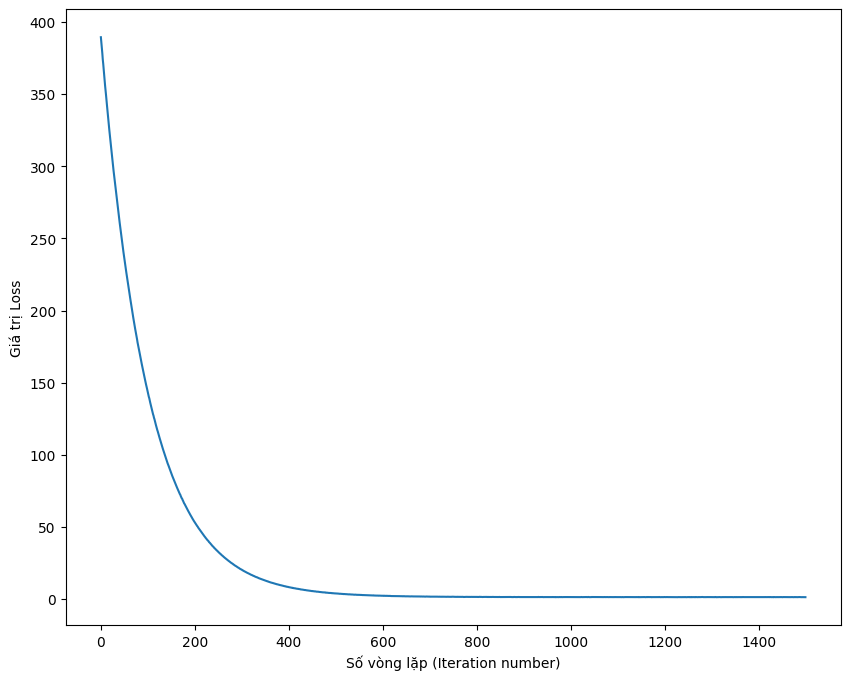

In [18]:
# Một kỹ nghệ debug mẹo hay ứng biến nên được áp dụng ở biểu đồ Loss đóng mang chức năng chạy the
# hiển hiện thay vì chỉ phụ thuộc đếm chay iteration numbers theo dòng:
plt.plot(loss_hist)
plt.xlabel('Số vòng lặp (Iteration number)')
plt.ylabel('Giá trị Loss')
plt.show()

In [19]:
# Triển biểu thức LinearClassifier.predict và đo đạc lại thành quả thể hiện
# ngay trên mặt cả tập dataset kiểm duyệt Train cũng tương đương validation set test
# Bạn kì thực được trông mong validation accuracy trả điểm độ chính xác vào đâu đó 0.34 (> 0.33) ở phần trước đấy nha.
y_train_pred = softmax.predict(X_train)
print('Độ chính xác trên tập training (training accuracy): %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('Độ chính xác trên tập xác thực (validation accuracy): %f' % (np.mean(y_val == y_val_pred), ))

Độ chính xác trên tập training (training accuracy): 0.498482
Độ chính xác trên tập xác thực (validation accuracy): 0.436364


In [20]:
# Bảo lưu mản thông số weight huấn luyện dành phần check của công cụ autograder.
softmax.save("softmax.npy")

In [21]:
# Biến tập kiểm Validation test set làm bệ cho bước cấy điều chuẩn chỉnh hyperparameters như là (regularization strength thông số độ lấn át /
# và tỷ lệ learning rate tốc dộ nhận). Lẽ khả thi trông mong việc tự tay check kiểm duyệt nhiều mức học tỉ lệ tốc (learning rate) rải phổ biên độ 
# lẫn dải tham biến của chấn song điều khiển regularization ; điều hướng khôn ngoan mạn có thể mang được mốc chẩn xác xấp xỉ phần độ chính xác
# ở ngưỡng 0.365 (> 0.36) rọi đo chuẩn test theo tập dữ liệu verification / validation data .

# Lời chú giải: thường hay bắt gặp dấy xuất hiện giông bão các báo warnings dội the kiểu báo ngóng (runtime/overflow warnings) xuyên bước quá độ hyper-parameter dò lưới này. 
# Phần tình cớ bắt điểm bởi vì lộn xộn các biến cực nhỏ/lớn, điều mang tính chất báo không nằm diện bugs .

# dữ kiện mapping vào chảo `results` kiểu tuples đóng diện mang format
# (learning_rate, regularization_strength) để tham gióng tới tuples form thứ hai là
# (training_accuracy, validation_accuracy). Chuẩn chẩn chính xác (accuracy) thực tiễn nói lên bao nhiêu phân vi mảnh của thông số
# dữ kiện data áp gán cho phân nhãn có xếp độ chuẩn.
results = {}
best_val = -1   # Dấu chân Validation rate điểm tối ưu tuyệt đối bắt kiểm nhất đạt .
best_softmax = None # Đối tượng (object) biến lưu cho phần Softmax gặt mang tầm chẩn vút đỉnh rate .

################################################################################
# CÁC BƯỚC TODO CẦN LÀM:                                                       #
# Thi hành mã lựa chắt hyperparameters xuất sắc mài dũa điền trên validation   #
# set. Thông vào dải quy kết chắp mạng kết hợp hyperparameters, cỗ máy luyện Model mạng Softmax sẽ lên. #
# tập train gốc, rồi lấy ra tính tổng bộ chính xác cho dòng data cả Training với bộ validation, từ đấy chắt #
# lại con hệ đếm cống hiến đưa lên nhét rương map data dictionary chùm tên là results kia . Có kèm nữa, nhớ nhét kho #
# Validation đỉnh gài trong best_val , chung tay vứt Softmax object đang khênh ngai vàng chẩn đỉnh ấy . #
# đặt vào cỗ best_softmax.                                                      #
#                                                                              #
# Nước Mẹo Bác Hint ngầm: Khuyên xới nháy thử dọn đà dạo ban đầu num_iters vói số khá bé trên bước đà đệm mở đầu code validation #
# để rảnh tay rút thời gian kẹt ngóng trôi khi mà the classifiers tập luyện mổ xẻ; hóng theo khi chừng nào validation ổn ổn #
# tự tay code chuẩn men, mới quay chạy nhồi bung phứa ra mả chạy với lớn biến num_iters.   #
################################################################################

# Đưa làm tham vấn gợi mở nền . Có hoặc hông tự muốn bóp mồi xoáy hyperparams biến độ 
learning_rates = [1e-7, 1e-6]
regularization_strengths = [2.5e4, 1e4]

################################################################################
# TODO: Tiến code xoáy hyperparameters lượn dũa chỉnh lại bước đo lóng...      #
################################################################################
# Thử nghiệm mọi sự kết hợp giữa Learning Rate (Tốc học) và Regularization (Chuẩn độ)
for lr in learning_rates:
    for reg in regularization_strengths:
        # Khởi tạo mô hình mạng
        softmax = Softmax()

        # Huấn luyện mô hình ngay trên cục Train
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg,
                      num_iters=1500, verbose=False)

        # Đánh giá lại nhẩm điểm trên tập Train
        y_train_pred = softmax.predict(X_train)
        train_acc = np.mean(y_train == y_train_pred)

        # Rưới trút lấy tính chẩn trên Validation
        y_val_pred = softmax.predict(X_val)
        val_acc = np.mean(y_val == y_val_pred)

        # Cấy giữ điểm map từ điển
        results[(lr, reg)] = (train_acc, val_acc)

        # Góp nhặt lật ngôi nêú model hiện có móc đỉnh điểm thành tích cao nhất Validation
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax
################################################################################

# Rưới chắt lôi kết xuất (results).
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('tốc học lr %e - chẩn reg %e \t| độ chuẩn xác train: %f \tđộ chuẩn xác validation: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('độ chuẩn xác tối đa lấy chắt ngóng thu nhặt lúc chạy quá trình đối chứng cross-validation: %f' % best_val)

tốc học lr 1.000000e-07 - chẩn reg 1.000000e+04 	| độ chuẩn xác train: 0.540486 	độ chuẩn xác validation: 0.436364
tốc học lr 1.000000e-07 - chẩn reg 2.500000e+04 	| độ chuẩn xác train: 0.498482 	độ chuẩn xác validation: 0.436364
tốc học lr 1.000000e-06 - chẩn reg 1.000000e+04 	| độ chuẩn xác train: 0.529858 	độ chuẩn xác validation: 0.422727
tốc học lr 1.000000e-06 - chẩn reg 2.500000e+04 	| độ chuẩn xác train: 0.494433 	độ chuẩn xác validation: 0.445455
độ chuẩn xác tối đa lấy chắt ngóng thu nhặt lúc chạy quá trình đối chứng cross-validation: 0.445455


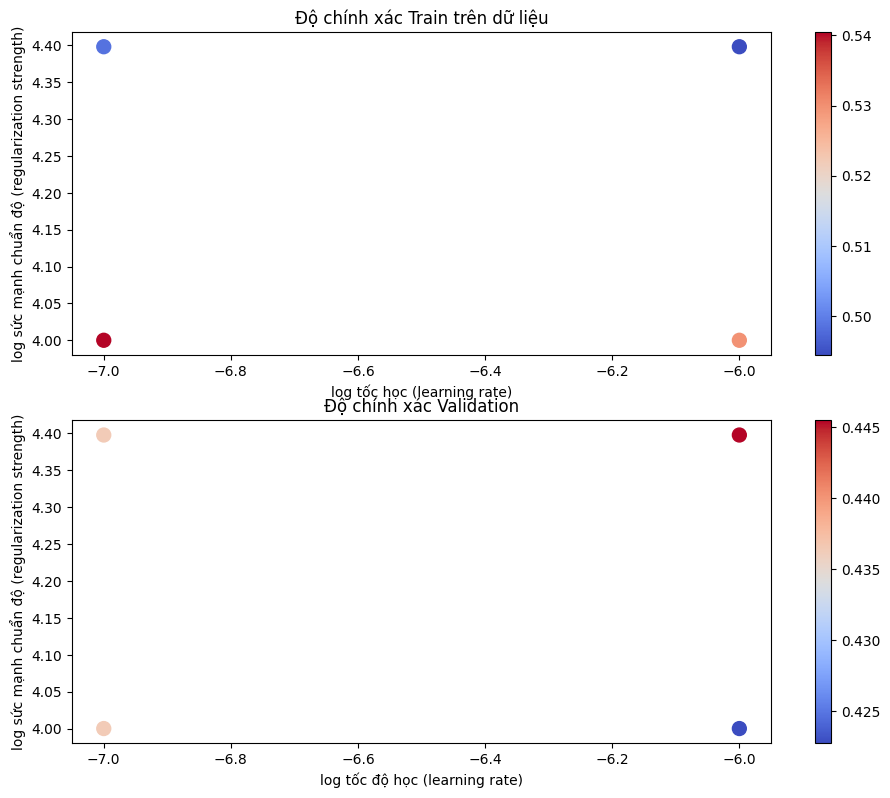

In [22]:
# Trực quan hóa họa kết quả lấy được từ bước chạy validation đối chiếu đa mẫu
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# Vẽ biểu diễn độ trúng chẩn huấn luyện training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log tốc học (learning rate)')
plt.ylabel('log sức mạnh chuẩn độ (regularization strength)')
plt.title('Độ chính xác Train trên dữ liệu')

# Vẽ biểu diễn độ trúng chẩn đối soát testing - validation accuracy
colors = [results[x][1] for x in results] # điểm markers căn cỡ mẫu ngầm là 20 
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log tốc độ học (learning rate)')
plt.ylabel('log sức mạnh chuẩn độ (regularization strength)')
plt.title('Độ chính xác Validation')
plt.show()

In [23]:
# Đo tính lóng kiểm lại Softmax tuyệt đỉnh trên sàn phơi bệ test data chưa từng diện kiến
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax mô phân loại gốc từ ảnh nguyên qua đánh giá tập chốt cuối Test mang ngai điểm (test set accuracy): %f' % test_accuracy)

Softmax mô phân loại gốc từ ảnh nguyên qua đánh giá tập chốt cuối Test mang ngai điểm (test set accuracy): 0.409091


In [24]:
# Lưu khảm mẫu đỉnh lưu cất lấy file save mô hình cao thủ best softmax model
best_softmax.save("best_softmax.npy")

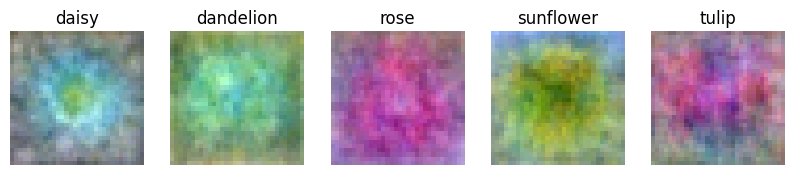

In [25]:
# Trực quan hóa hình lộ rõ điểm ảnh của trọng số lượm thu cho lần lượt từng loài phân lớp classes mảng.
# Quãng tùy gàn định cho việc chọn dải tốc learning rate rồi chuẩn độ regularization strength, các mảng rọi hiển hiện đôi lúc có thể 
# hoặc ngáo hiện lại là nhìn rất nhã nhặn bắt xem vui tay trông hay tới.
w = best_softmax.W[:-1,:] # bóc bung đường viền góc cạnh bias đi chừa lại mỗi khối core
w = w.reshape(32, 32, 3, 5)
w_min, w_max = np.min(w), np.max(w)
classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
for i in range(5):
    plt.subplot(1, 5, i + 1)

    # Tái canh chiếu (Rescale) bộ trọng số weight trải từ 0 tời vạch mốc 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Câu hỏi Trực tiếp 3**

Hãy mô tả miêu tả hình ảnh thị giác dáng vẻ ma trận trọng số Classifier Softmax ra hình dáng thế nào, theo sau đó biếu thêm lời dẫn đính kèm làm vì sao biểu tượng ảnh chúng kết tụ trôn nhìn như vậy là lý do gì ở phía dưới.

$\color{blue}{\textit Câu trả lời của bạn:}$ *điền phần này xuống dưới*  

**Câu hỏi Trực tiếp 4** - *Đúng (True) hay Sai (False)*

Thiết sử đặt giả thiết có điểm loss đếm trọn vòng (overall) khi gánh train định nghĩa tréo tổng phần giá trị loss thất thoát trên mỗi điểm dữ liệu gom trải qua hết tập data train đã cho. Đặt việc thử thêm cắm chèn điểm data mới lạ vào dải train và thứ này đụng tác động lay động khiến dời đổi giá trị của hàm mất mát softmax (softmax loss), nhưng lại chừa cho khoảng hao của SVM đứng yên lì không thèm thay đổi.

$\color{blue}{\textit Câu trả lời của bạn:}$


$\color{blue}{\textit Lời giải thích của bạn (Explanation):}$